# Right Whale Acoustics Data Exporation and Pipeline for Learning

In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 74.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 47.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 108.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 3.3 MB/s eta 0:00:0000

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


In [3]:
#General data source
#https://console.cloud.google.com/storage/browser/noaa-passive-bioacoustic/dclde/2013

#Detection logs
#NEFSC_SBNMS_200903_NOPP6_CH10_upcall-detection-log*.csv

#Audio
#https://storage.googleapis.com/noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/*.wav

!mkdir -p /kaggle/working/audio
!gsutil -m cp \
gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/*.wav \
/kaggle/working/audio/

!mkdir -p /kaggle/working/detections
!gsutil -m cp \
gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/detections/*.csv \
/kaggle/working/detections/

!mkdir -p /kaggle/working/metadata
!gsutil -m cp \
gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/metadata/*.json

Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_001500_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_000000_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_004500_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_003000_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_010000_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_013000_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audio/NOPP6_EST_20090328_014500_CH10.wav...
Copying gs://noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/source-audi

Loaded 40000 samples
Sample rate: 2000
Duration: 20.00 sec


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


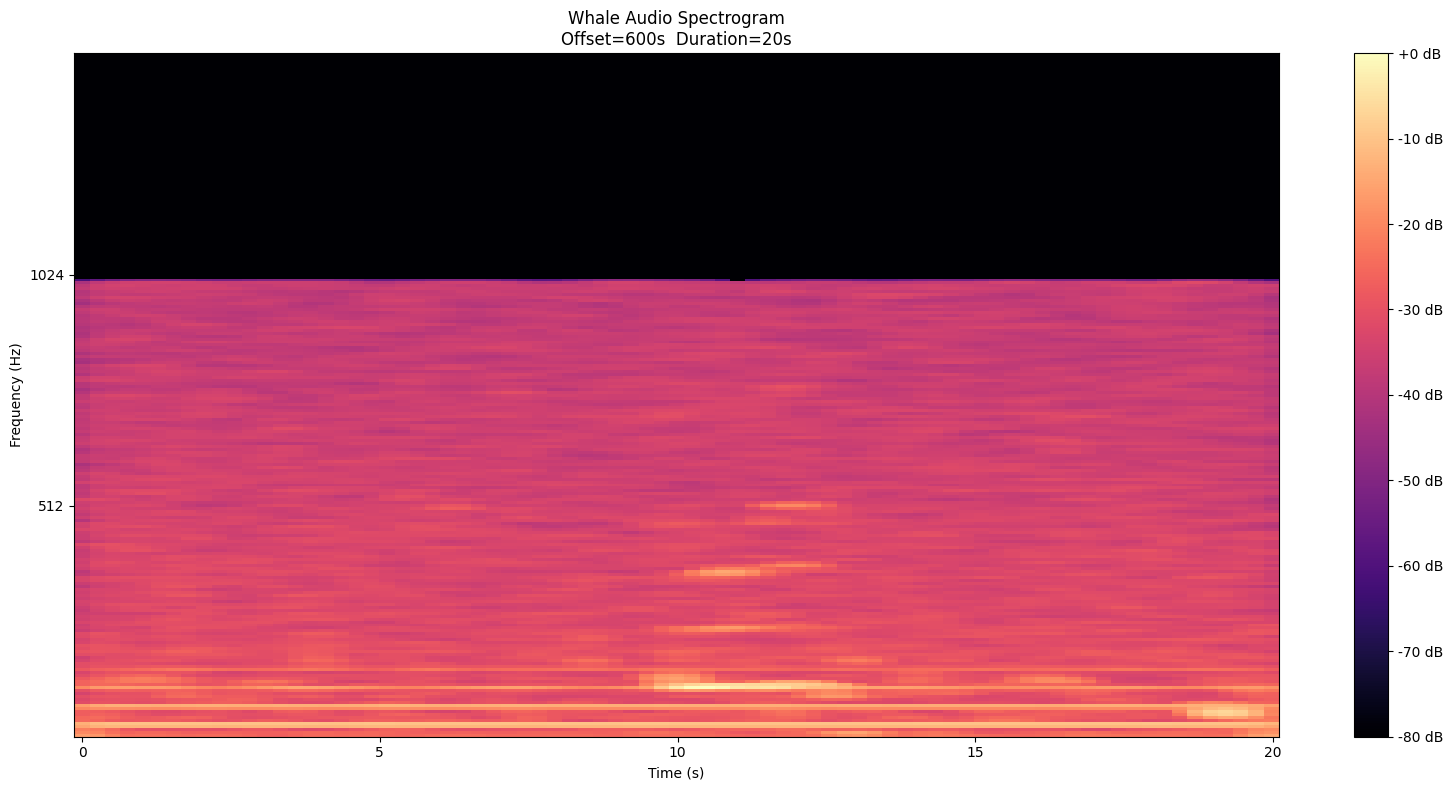

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------
# AUDIO FILE
# ---------------------------------------

audio_path = "/kaggle/working/audio/NOPP6_EST_20090328_000000_CH10.wav"

# ---------------------------------------
# WINDOW SETTINGS
# ---------------------------------------

offset_sec = 600      # start 10 minutes into file
duration_sec = 20     # 20 second window

# whale calls are often low frequency
fmax = 2000

# ---------------------------------------
# LOAD ONLY THE WINDOW
# ---------------------------------------

y, sr = librosa.load(
    audio_path,
    sr=None,
    offset=offset_sec,
    duration=duration_sec
)

print(f"Loaded {len(y)} samples")
print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.2f} sec")

# ---------------------------------------
# CREATE MEL SPECTROGRAM
# ---------------------------------------

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=4096,
    hop_length=512,
    n_mels=256,
    fmin=10,
    fmax=fmax
)

S_db = librosa.power_to_db(S, ref=np.max)

# ---------------------------------------
# PLOT SPECTROGRAM
# ---------------------------------------

plt.figure(figsize=(16,8))

img = librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel',
    fmin=10,
    fmax=fmax
)

plt.colorbar(img, format='%+2.0f dB')

plt.title(
    f"Whale Audio Spectrogram\n"
    f"Offset={offset_sec}s  Duration={duration_sec}s"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_57/3387333886.py:109: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


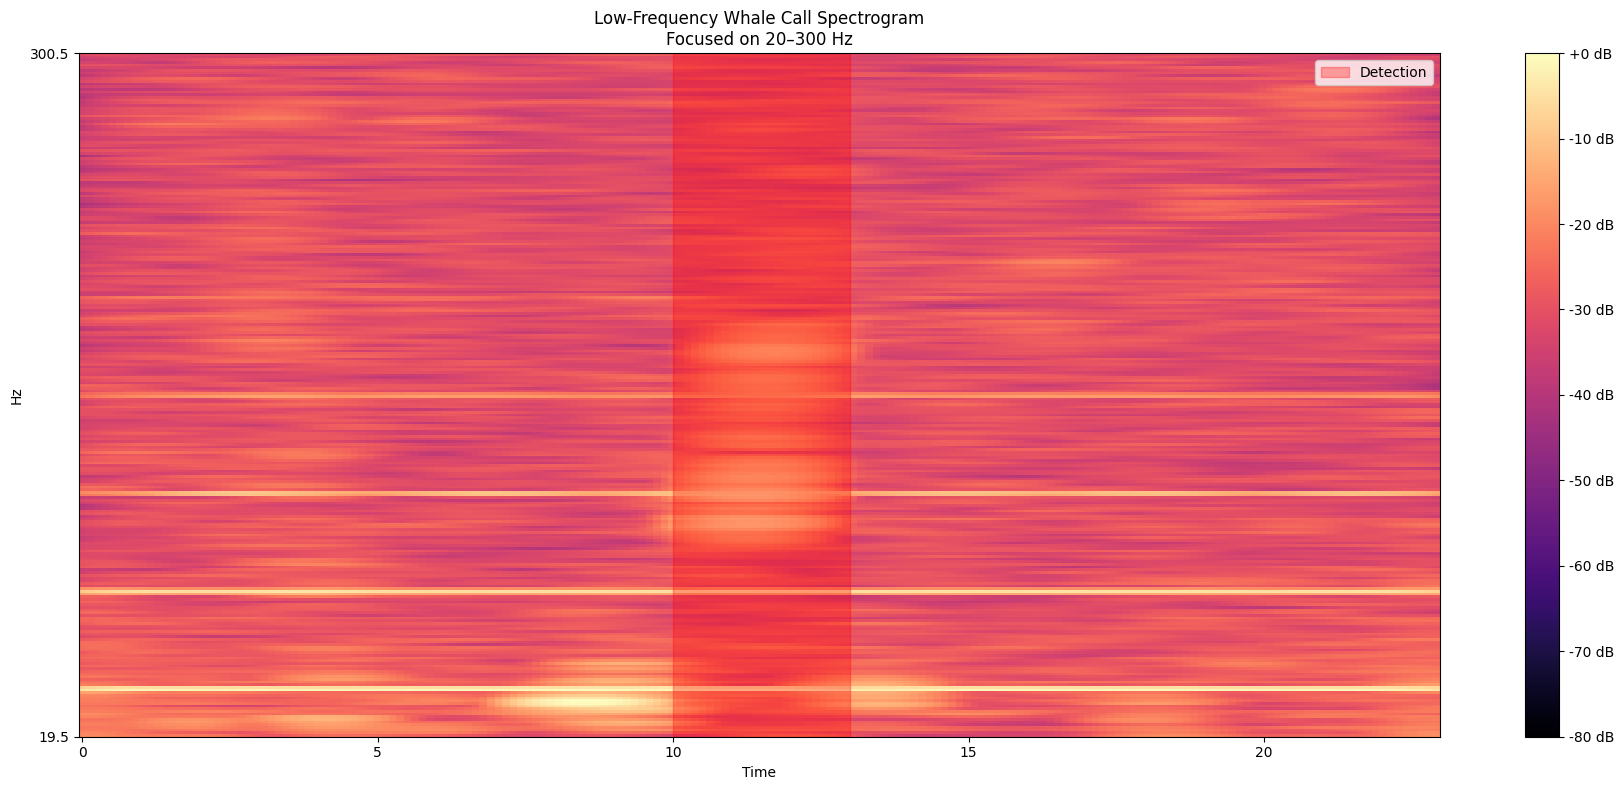

In [5]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# DETECTION
# ---------------------------------------------------

call_start = pd.Timestamp("2009-03-28T00:03:55-05:00")
call_end   = pd.Timestamp("2009-03-28T00:03:58-05:00")

wav_start = pd.Timestamp("2009-03-28T00:00:00-05:00")

audio_path = (
    "/kaggle/working/audio/"
    "NOPP6_EST_20090328_000000_CH10.wav"
)

# ---------------------------------------------------
# COMPUTE OFFSET
# ---------------------------------------------------

offset_sec = (call_start - wav_start).total_seconds()

# ---------------------------------------------------
# LOAD WINDOW
# ---------------------------------------------------

pre_buffer = 10
post_buffer = 10

load_offset = max(0, offset_sec - pre_buffer)

duration = (
    (call_end - call_start).total_seconds()
    + pre_buffer
    + post_buffer
)

y, sr = librosa.load(
    audio_path,
    sr=None,
    offset=load_offset,
    duration=duration
)

# ---------------------------------------------------
# HIGH-RES LOW-FREQUENCY SPECTROGRAM
# ---------------------------------------------------

fmax = 300

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=8192,        # better low-frequency resolution
    hop_length=256,
    n_mels=256,
    fmin=20,
    fmax=fmax
)

S_db = librosa.power_to_db(S, ref=np.max)

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------

plt.figure(figsize=(18,8))

img = librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=256,
    x_axis='time',
    y_axis='mel',
    fmin=20,
    fmax=fmax
)

plt.colorbar(img, format='%+2.0f dB')

# increase contrast
plt.clim(-80, 0)

# mark detection region
call_relative_start = pre_buffer
call_relative_end = pre_buffer + (
    call_end - call_start
).total_seconds()

plt.axvspan(
    call_relative_start,
    call_relative_end,
    color='red',
    alpha=0.3,
    label='Detection'
)

plt.legend()

plt.title(
    "Low-Frequency Whale Call Spectrogram\n"
    "Focused on 20–300 Hz"
)

plt.tight_layout()
plt.show()

In [6]:
import os
import pandas as pd
from datetime import datetime, timedelta
import re

audio_dir = "/kaggle/working/audio"

def parse_file_time(fname):
    """
    Extract YYYYMMDD_HHMMSS from filename like:
    NOPP6_EST_20090328_000000_CH10.wav
    """
    match = re.search(r"(\d{8})_(\d{6})", fname)
    if not match:
        return None

    date_str = match.group(1)
    time_str = match.group(2)

    return datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")


file_rows = []

for f in os.listdir(audio_dir):
    if f.endswith(".wav"):
        start = parse_file_time(f)
        if start is None:
            continue

        end = start + timedelta(minutes=15)

        file_rows.append({
            "file_path": os.path.join(audio_dir, f),
            "filename": f,
            "start_time": start,
            "end_time": end
        })

file_df = pd.DataFrame(file_rows)

file_df.head()

,file_path,filename,start_time,end_time
0,/kaggle/working/audio/NOPP6_EST_20090330_08450...,NOPP6_EST_20090330_084500_CH10.wav,2009-03-30 08:45:00,2009-03-30 09:00:00
1,/kaggle/working/audio/NOPP6_EST_20090330_06300...,NOPP6_EST_20090330_063000_CH10.wav,2009-03-30 06:30:00,2009-03-30 06:45:00
2,/kaggle/working/audio/NOPP6_EST_20090403_08450...,NOPP6_EST_20090403_084500_CH10.wav,2009-04-03 08:45:00,2009-04-03 09:00:00
3,/kaggle/working/audio/NOPP6_EST_20090402_23450...,NOPP6_EST_20090402_234500_CH10.wav,2009-04-02 23:45:00,2009-04-03 00:00:00
4,/kaggle/working/audio/NOPP6_EST_20090331_13450...,NOPP6_EST_20090331_134500_CH10.wav,2009-03-31 13:45:00,2009-03-31 14:00:00


In [7]:
ann_path = "/kaggle/working/detections/NEFSC_SBNMS_200903_NOPP6_CH10_upcall-detection-log.csv"

df = pd.read_csv(ann_path)

df["start"] = pd.to_datetime(df["Start_DateTime_ISO8601"], utc=True)
df["end"] = pd.to_datetime(df["End_DateTime_ISO8601"], utc=True)

df.head()

,Selection,View,Channel,Start_DateTime_ISO8601,End_DateTime_ISO8601,Low.Freq..Hz.,High.Freq..Hz.,Species,Detection_Confidence,start,end
0,1,Spectrogram 1,1,2009-03-28T00:03:08-05:00,2009-03-28T00:03:11-05:00,70.7,174.2,RIWH,Detected,2009-03-28 05:03:08+00:00,2009-03-28 05:03:11+00:00
1,2,Spectrogram 1,1,2009-03-28T00:03:55-05:00,2009-03-28T00:03:58-05:00,83.3,197.0,RIWH,Detected,2009-03-28 05:03:55+00:00,2009-03-28 05:03:58+00:00
2,3,Spectrogram 1,1,2009-03-28T00:06:38-05:00,2009-03-28T00:06:41-05:00,75.8,151.5,RIWH,Detected,2009-03-28 05:06:38+00:00,2009-03-28 05:06:41+00:00
3,4,Spectrogram 1,1,2009-03-28T00:07:17-05:00,2009-03-28T00:07:21-05:00,75.8,214.6,RIWH,Detected,2009-03-28 05:07:17+00:00,2009-03-28 05:07:21+00:00
4,5,Spectrogram 1,1,2009-03-28T00:07:30-05:00,2009-03-28T00:07:33-05:00,40.4,171.7,RIWH,Detected,2009-03-28 05:07:30+00:00,2009-03-28 05:07:33+00:00


In [8]:
import os
import re
import pandas as pd
from datetime import datetime, timedelta, timezone

audio_dir = "/kaggle/working/audio"

def parse_file_time(fname):
    # NOPP6_EST_20090328_000000_CH10.wav
    match = re.search(r"(\d{8})_(\d{6})", fname)
    if not match:
        return None

    dt = datetime.strptime(match.group(1) + match.group(2), "%Y%m%d%H%M%S")
    return dt.replace(tzinfo=timezone.utc)

file_rows = []

for f in os.listdir(audio_dir):
    if not f.endswith(".wav"):
        continue

    start = parse_file_time(f)
    if start is None:
        continue

    file_rows.append({
        "file_path": os.path.join(audio_dir, f),
        "filename": f,
        "start_time": start,
        "end_time": start + timedelta(minutes=15)
    })

file_df = pd.DataFrame(file_rows).sort_values("start_time").reset_index(drop=True)

print(file_df.head())

                                           file_path  \
0  /kaggle/working/audio/NOPP6_EST_20090328_00000...   
1  /kaggle/working/audio/NOPP6_EST_20090328_00150...   
2  /kaggle/working/audio/NOPP6_EST_20090328_00300...   
3  /kaggle/working/audio/NOPP6_EST_20090328_00450...   
4  /kaggle/working/audio/NOPP6_EST_20090328_01000...   

                             filename                start_time  \
0  NOPP6_EST_20090328_000000_CH10.wav 2009-03-28 00:00:00+00:00   
1  NOPP6_EST_20090328_001500_CH10.wav 2009-03-28 00:15:00+00:00   
2  NOPP6_EST_20090328_003000_CH10.wav 2009-03-28 00:30:00+00:00   
3  NOPP6_EST_20090328_004500_CH10.wav 2009-03-28 00:45:00+00:00   
4  NOPP6_EST_20090328_010000_CH10.wav 2009-03-28 01:00:00+00:00   

                   end_time  
0 2009-03-28 00:15:00+00:00  
1 2009-03-28 00:30:00+00:00  
2 2009-03-28 00:45:00+00:00  
3 2009-03-28 01:00:00+00:00  
4 2009-03-28 01:15:00+00:00  


In [9]:
ann_path = "/kaggle/working/detections/NEFSC_SBNMS_200903_NOPP6_CH10_upcall-detection-log.csv"

df = pd.read_csv(ann_path)

df["start"] = pd.to_datetime(df["Start_DateTime_ISO8601"], utc=True)
df["end"] = pd.to_datetime(df["End_DateTime_ISO8601"], utc=True)

df = df.sort_values("start").reset_index(drop=True)

print(df.head())

   Selection           View  Channel     Start_DateTime_ISO8601  \
0          1  Spectrogram 1        1  2009-03-28T00:03:08-05:00   
1          2  Spectrogram 1        1  2009-03-28T00:03:55-05:00   
2          3  Spectrogram 1        1  2009-03-28T00:06:38-05:00   
3          4  Spectrogram 1        1  2009-03-28T00:07:17-05:00   
4          5  Spectrogram 1        1  2009-03-28T00:07:30-05:00   

        End_DateTime_ISO8601  Low.Freq..Hz.  High.Freq..Hz. Species  \
0  2009-03-28T00:03:11-05:00           70.7           174.2    RIWH   
1  2009-03-28T00:03:58-05:00           83.3           197.0    RIWH   
2  2009-03-28T00:06:41-05:00           75.8           151.5    RIWH   
3  2009-03-28T00:07:21-05:00           75.8           214.6    RIWH   
4  2009-03-28T00:07:33-05:00           40.4           171.7    RIWH   

  Detection_Confidence                     start                       end  
0             Detected 2009-03-28 05:03:08+00:00 2009-03-28 05:03:11+00:00  
1             De

In [10]:
#Match overlapping files
file_df["key"] = 1
df["key"] = 1

merged = df.merge(file_df, on="key").drop("key", axis=1)

# overlap condition:
overlap = (
    (merged["end"] > merged["start_time"]) &
    (merged["start"] < merged["end_time"])
)

matched = merged[overlap].copy()

In [11]:
file_to_annotations = {
    f: [] for f in file_df["file_path"]
}

for _, row in matched.iterrows():
    file_to_annotations[row["file_path"]].append(
        (row["start"], row["end"])
    )

In [12]:
#Filter for labeled files only

labeled_files = [
    f for f, anns in file_to_annotations.items()
    if len(anns) > 0
]

print("Total labeled files:", len(labeled_files))

Total labeled files: 494


In [13]:
#Split by file to avoid data leaks
from sklearn.model_selection import train_test_split

train_files, temp_files = train_test_split(
    labeled_files,
    test_size=0.3,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

print(len(train_files), len(val_files), len(test_files))

345 74 75


In [14]:
#Save dataset information for later
import json

with open("/kaggle/working/file_splits.json", "w") as f:
    json.dump(splits, f, indent=2)

In [15]:
serializable = {
    k: [(str(s), str(e)) for s, e in v]
    for k, v in file_to_annotations.items()
}

with open("/kaggle/working/file_annotations.json", "w") as f:
    json.dump(serializable, f, indent=2)

In [16]:
def split_stats(split_name, files):
    ann_counts = [len(file_to_annotations[f]) for f in files]

    print(f"{split_name.upper()}")
    print(f"  Avg annotations per file: {sum(ann_counts)/len(ann_counts):.2f}")
    print(f"  Max annotations in a file: {max(ann_counts)}")
    print(f"  Zero-call files: {sum(1 for x in ann_counts if x == 0)}")
    print("-" * 40)

for name, files in splits.items():
    split_stats(name, files)

TRAIN
  Avg annotations per file: 16.51
  Max annotations in a file: 77
  Zero-call files: 0
----------------------------------------
VAL
  Avg annotations per file: 17.64
  Max annotations in a file: 62
  Zero-call files: 0
----------------------------------------
TEST
  Avg annotations per file: 16.28
  Max annotations in a file: 76
  Zero-call files: 0
----------------------------------------


In [17]:
import numpy as np
import torch
import librosa
from torch.utils.data import Dataset

In [18]:
def has_overlap(win_start, win_end, annotations):
    for a_start, a_end in annotations:
        if (a_end > win_start) and (a_start < win_end):
            return 1
    return 0

In [19]:
file_to_ann_seconds = {}

for f in file_df.itertuples():
    anns = file_to_annotations.get(f.file_path, [])

    file_start = f.start_time

    ann_seconds = []
    for a_start, a_end in anns:
        ann_seconds.append((
            (a_start - file_start).total_seconds(),
            (a_end - file_start).total_seconds()
        ))

    file_to_ann_seconds[f.file_path] = ann_seconds

In [20]:
class WhaleTCNDataset(Dataset):
    def __init__(
        self,
        file_list,
        file_to_ann_seconds,
        file_start_times,
        sample_rate=2000,
        window_size_sec=5,
        hop_size_sec=2.5,
        n_mels=64
    ):
        self.file_list = file_list
        self.file_to_ann_seconds = file_to_ann_seconds
        self.file_start_times = file_start_times

        self.sr = sample_rate
        self.window_size_sec = window_size_sec
        self.hop_size_sec = hop_size_sec
        self.n_mels = n_mels

        self.index = self._build_index()

    def _build_index(self):
        index = []

        for file_path in self.file_list:
            y, sr = librosa.load(file_path, sr=self.sr)

            anns = self.file_to_ann_seconds[file_path]

            win_size = int(self.window_size_sec * sr)
            hop_size = int(self.hop_size_sec * sr)

            for start in range(0, len(y) - win_size, hop_size):
                end = start + win_size

                win_start = start / sr
                win_end = end / sr

                label = has_overlap(win_start, win_end, anns)

                index.append((file_path, start, end, label))

        return index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        file_path, start, end, label = self.index[idx]

        y, sr = librosa.load(file_path, sr=self.sr)
        segment = y[start:end]

        # mel spectrogram
        S = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=self.n_mels,
            n_fft=512,
            hop_length=128
        )

        S = librosa.power_to_db(S)

        # (T, F)
        S = torch.tensor(S.T, dtype=torch.float32)

        return S, torch.tensor(label, dtype=torch.float32)

In [21]:
train_ds = WhaleTCNDataset(train_files, file_to_ann_seconds, file_start_times=None)
val_ds   = WhaleTCNDataset(val_files, file_to_ann_seconds, file_start_times=None)
test_ds  = WhaleTCNDataset(test_files, file_to_ann_seconds, file_start_times=None)

In [22]:
import os
import numpy as np
import librosa

cache_dir = "/kaggle/working/spectrogram_cache"
os.makedirs(cache_dir, exist_ok=True)

In [23]:
SR = 2000
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 128

In [24]:
def compute_and_save_spec(file_path):
    fname = os.path.basename(file_path).replace(".wav", ".npy")
    out_path = os.path.join(cache_dir, fname)

    if os.path.exists(out_path):
        return out_path

    y, sr = librosa.load(file_path, sr=SR)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    S = librosa.power_to_db(S)

    np.save(out_path, S.astype(np.float32))

    return out_path

In [25]:
file_to_spec = {}

for file_path in file_df["file_path"]:
    spec_path = compute_and_save_spec(file_path)
    file_to_spec[file_path] = spec_path

print("Done caching spectrograms:", len(file_to_spec))

Done caching spectrograms: 672


In [26]:
import torch
from torch.utils.data import Dataset

class CachedWhaleDataset(Dataset):
    def __init__(
        self,
        file_list,
        file_to_spec,
        file_to_ann_seconds,
        window_size_sec=5,
        hop_size_sec=2.5
    ):
        self.file_list = file_list
        self.file_to_spec = file_to_spec
        self.file_to_ann_seconds = file_to_ann_seconds

        self.window_size = int(window_size_sec * SR / HOP_LENGTH)
        self.hop_size = int(hop_size_sec * SR / HOP_LENGTH)

        self.index = self._build_index()

    def _build_index(self):
        index = []

        for f in self.file_list:
            spec = np.load(self.file_to_spec[f])  # (n_mels, time)
            anns = self.file_to_ann_seconds[f]

            T = spec.shape[1]

            for t in range(0, T - self.window_size, self.hop_size):
                t_start_sec = t * HOP_LENGTH / SR
                t_end_sec = (t + self.window_size) * HOP_LENGTH / SR

                label = 0
                for a_start, a_end in anns:
                    if (a_end > t_start_sec) and (a_start < t_end_sec):
                        label = 1
                        break

                index.append((f, t, label))

        return index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        file_path, t, label = self.index[idx]

        spec = np.load(self.file_to_spec[file_path])  # (F, T)

        window = spec[:, t:t+self.window_size]  # (F, time)

        window = torch.tensor(window.T, dtype=torch.float32)  # (time, F)

        return window, torch.tensor(label, dtype=torch.float32)

In [27]:
train_ds = CachedWhaleDataset(train_files, file_to_spec, file_to_ann_seconds)
val_ds   = CachedWhaleDataset(val_files, file_to_spec, file_to_ann_seconds)
test_ds  = CachedWhaleDataset(test_files, file_to_spec, file_to_ann_seconds)

In [28]:
from collections import Counter

def compute_class_weights(dataset):
    labels = [dataset[i][1].item() for i in range(len(dataset))]
    counts = Counter(labels)

    total = sum(counts.values())
    pos_weight = counts[0] / max(counts[1], 1)

    print("Class distribution:", counts)
    print("Pos weight:", pos_weight)

    return pos_weight

In [29]:
import torch
import torch.nn as nn

pos_weight = compute_class_weights(train_ds)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))

Class distribution: Counter({0.0: 109153, 1.0: 14702})
Pos weight: 7.424364032104475


In [30]:
from torch.utils.data import WeightedRandomSampler

labels = [train_ds[i][1].item() for i in range(len(train_ds))]
class_count = Counter(labels)

weights = [1.0 / class_count[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights))

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_ch,
            out_ch,
            kernel_size=3,
            padding=dilation,
            dilation=dilation
        )

        self.conv2 = nn.Conv1d(
            out_ch,
            out_ch,
            kernel_size=3,
            padding=dilation,
            dilation=dilation
        )

        self.norm1 = nn.BatchNorm1d(out_ch)
        self.norm2 = nn.BatchNorm1d(out_ch)

        self.residual = nn.Conv1d(in_ch, out_ch, kernel_size=1) \
            if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.residual(x)

        x = self.conv1(x)
        x = self.norm1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = self.norm2(x)

        return F.relu(x + res)

In [32]:
class WhaleTCN(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.net = nn.Sequential(
            TCNBlock(n_features, 64, dilation=1),
            TCNBlock(64, 64, dilation=2),
            TCNBlock(64, 64, dilation=4),
            TCNBlock(64, 64, dilation=8),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, time, features)
        x = x.permute(0, 2, 1)  # -> (batch, features, time)

        x = self.net(x)
        x = self.head(x)

        return x.squeeze(-1)

In [33]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=sampler if "sampler" in globals() else None,
    shuffle=("sampler" not in globals()),
    num_workers=2
)

val_loader = DataLoader(val_ds, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WhaleTCN(n_features=64).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [36]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WhaleTCN(n_features=64).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []

EPOCHS = 100
PRINT_EVERY = 20

for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    epoch_loss = 0.0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader))

    for step, (x, y) in pbar:

        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_value = loss.item()

        running_loss += loss_value
        epoch_loss += loss_value

        # show progress every few steps
        if step % PRINT_EVERY == 0:
            avg_running = running_loss / max(1, PRINT_EVERY)

            pbar.set_description(
                f"Epoch {epoch+1} Step {step} "
                f"Train Loss: {avg_running:.4f}"
            )

            running_loss = 0.0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} "
        f"| Train Loss: {avg_train_loss:.4f} "
        f"| Val Loss: {avg_val_loss:.4f}"
    )

  0%|          | 0/3871 [00:00<?, ?it/s]


Epoch 1/10 | Train Loss: 1.5500 | Val Loss: 2.1272


  0%|          | 0/3871 [00:00<?, ?it/s]


Epoch 2/10 | Train Loss: 1.5338 | Val Loss: 1.9850


  0%|          | 0/3871 [00:00<?, ?it/s]

...


Epoch 8/10 | Train Loss: 1.5100 | Val Loss: 1.9926


  0%|          | 0/3871 [00:00<?, ?it/s]


Epoch 9/10 | Train Loss: 1.5071 | Val Loss: 2.0200


  0%|          | 0/3871 [00:00<?, ?it/s]


Epoch 10/10 | Train Loss: 1.4987 | Val Loss: 2.0876


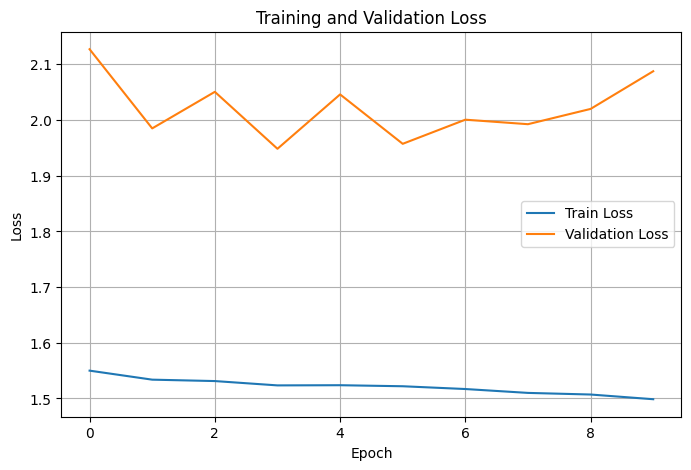

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [41]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, loader, threshold=0.5):

    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            probs = torch.sigmoid(logits)

            preds = (probs > threshold).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    precision = precision_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    cm = confusion_matrix(all_targets, all_preds)

    print("\n===== EVALUATION =====")
    print(f"Threshold: {threshold:.2f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(
        all_targets,
        all_preds,
        zero_division=0
    ))

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "probs": all_probs,
        "targets": all_targets
    }

In [42]:
results = evaluate_model(
    model,
    val_loader,
    threshold=0.5
)


===== EVALUATION =====
Threshold: 0.50
Precision: 0.1265
Recall:    0.9923
F1 Score:  0.2244

Confusion Matrix
[[  204 23005]
 [   26  3331]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.89      0.01      0.02     23209
         1.0       0.13      0.99      0.22      3357

    accuracy                           0.13     26566
   macro avg       0.51      0.50      0.12     26566
weighted avg       0.79      0.13      0.04     26566

